# Stage 1 — Seizure Detection (binary)

Trains and tests a 1D CNN that classifies a 4 s, 18-channel EEG window as **seizure** or
**non-seizure**, using the harmonized windows `src/preprocessing.ipynb` produced
(`data/harmonized/windows/stage1_windows.parquet`, both CHB-MIT and Siena).

Everything needed to run an experiment is in the **Config** cell below — change a value there
and re-run the notebook top to bottom; nothing else needs editing. Training and testing both
live in this one file: the training loop records per-epoch metrics and plots them, then the
best checkpoint is reloaded and evaluated once, fully, on a held-out test set.

**Split:** subject-level (`subject_key`), stratified by dataset so both CHB-MIT and Siena
subjects land in train/val/test — never a random window split, or overlapping windows from
one seizure would leak across the split and inflate every metric (`preprocessing.ipynb` §9).

**Imbalance:** seizure:non-seizure is about 1:71. A `WeightedRandomSampler` balances what the
model sees per batch; accuracy alone is never reported for exactly this reason (predicting
"never seizure" scores >98%) — sensitivity, specificity, AUROC and F1 are.

## Config

The only cell meant to be edited between runs.

In [1]:
import gc
import json
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              roc_auc_score, roc_curve)

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

# ---- paths --------------------------------------------------------------------------
WIN_ROOT = Path("../data/harmonized/windows")
CKPT_DIR = Path("../checkpoints/stage1_cnn1d_detection")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ---- reproducibility ------------------------------------------------------------------
SEED = 20260803

# ---- split --------------------------------------------------------------------------
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15                 # remainder -> test; split is per-subject

# ---- data volume per epoch ------------------------------------------------------------
# Windows are read on demand from HDF5 (the full table is ~68 GB, far too big to preload),
# and a random 4 s slice costs ~8 ms to read. These caps bound epoch time; raise them for a
# more thorough (slower) run, or set TEST_EVAL_MAX_SAMPLES=None for the complete test set.
# VAL_SAMPLE_SIZE was 3,000: small enough that val AUROC swung +/-0.05 epoch to epoch on pure
# sampling noise, which made "best checkpoint" partly a coin flip. Raised to give checkpoint
# selection (and the plotted curves) a stable enough signal to actually trust.
BATCH_SIZE = 64
TRAIN_STEPS_PER_EPOCH = 300                         # -> TRAIN_STEPS_PER_EPOCH * BATCH_SIZE windows/epoch
VAL_SAMPLE_SIZE = 8000                              # fixed subsample, resampled once, for fast per-epoch tracking
TEST_EVAL_MAX_SAMPLES = 15000                       # final test is stratified-subsampled to this many; None = full test set

# ---- model ----------------------------------------------------------------------------
MODEL_WIDTH = 32                                    # base channel width; deeper layers are 2x/4x/8x this
DROPOUT = 0.35                                      # raised slightly alongside WEIGHT_DECAY -- see note below

# ---- optimization -----------------------------------------------------------------------
# Train loss fell smoothly to ~0.014 while val loss climbed and got noisier the whole run
# (see the previous training_curves.png) -- textbook overfitting, not fixed by the epoch/data
# increase above. WEIGHT_DECAY and DROPOUT are both raised to push back on it directly.
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 3e-4
N_EPOCHS = 25
PATIENCE = 10                                       # early stop if val AUROC hasn't improved in this many epochs
# FOCAL_ALPHA=0.25 was reweighting classes *again* on top of WeightedRandomSampler, which
# already balances every batch -- two class-imbalance corrections stacked, which likely added
# to the epoch-to-epoch sensitivity/specificity swings. alpha=0.5 removes that double
# correction and leaves only GAMMA doing what focal loss is actually for: down-weighting
# already-easy examples so training focuses on the hard ones.
FOCAL_ALPHA = 0.5
FOCAL_GAMMA = 2.0                                   # focal loss: focusing strength (0 == plain BCE)

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))


device: cuda (NVIDIA GeForce RTX 5060 Ti)


## Data

Loads the window manifest `preprocessing.ipynb` produced. Nothing here reads raw EDF.

In [2]:
S1 = pd.read_parquet(WIN_ROOT / "stage1_windows.parquet")
MANIFEST = json.loads((WIN_ROOT / "manifest.json").read_text())
N_CH = MANIFEST["n_channels"]
N_TIMEPOINTS = int(round(MANIFEST["stage1"]["window_s"] * MANIFEST["sfreq"]))

print(f"{len(S1):,} windows | {N_CH} channels | {N_TIMEPOINTS} timepoints/window "
      f"({MANIFEST['stage1']['window_s']:.0f}s @ {MANIFEST['sfreq']:.0f} Hz)")
print(S1.groupby("dataset").label.value_counts().unstack(fill_value=0))


928,154 windows | 18 channels | 1024 timepoints/window (4s @ 256 Hz)
label            0     1
dataset                 
CHB-MIT     800731  8732
SienaScalp  114489  4202


### Subject-level, dataset-stratified split

Splitting each dataset's subject list separately (then taking the union) guarantees both
CHB-MIT and Siena subjects appear in train/val/test — a single shuffle over all 38 subjects
could, by chance, put zero Siena subjects in one split, since Siena is the minority (14 vs 24
CHB subjects).

In [3]:
def subject_split(df, train_frac, val_frac, seed):
    rng = np.random.default_rng(seed)
    train_s, val_s, test_s = set(), set(), set()
    for dataset, g in df.groupby("dataset"):
        subs = rng.permutation(sorted(g.subject_key.unique()))
        n = len(subs)
        n_train = max(1, int(round(n * train_frac)))
        n_val = max(1, int(round(n * val_frac)))
        train_s.update(subs[:n_train])
        val_s.update(subs[n_train:n_train + n_val])
        test_s.update(subs[n_train + n_val:])
    assert not (train_s & val_s) and not (train_s & test_s) and not (val_s & test_s), \
        "subject leakage across splits"
    return train_s, val_s, test_s

train_subj, val_subj, test_subj = subject_split(S1, TRAIN_FRAC, VAL_FRAC, SEED)

train_df = S1[S1.subject_key.isin(train_subj)].reset_index(drop=True)
val_df = S1[S1.subject_key.isin(val_subj)].reset_index(drop=True)
test_df = S1[S1.subject_key.isin(test_subj)].reset_index(drop=True)

for name, subs, df in [("train", train_subj, train_df), ("val", val_subj, val_df), ("test", test_subj, test_df)]:
    by_ds = pd.Series(sorted(subs)).str.split("/").str[0].value_counts()
    print(f"{name:5s}: {len(subs):2d} subjects ({dict(by_ds)}) | {len(df):,} windows | "
          f"{int((df.label == 1).sum()):,} seizure")


train: 27 subjects ({'CHB-MIT': np.int64(17), 'SienaScalp': np.int64(10)}) | 693,155 windows | 9,017 seizure
val  :  6 subjects ({'CHB-MIT': np.int64(4), 'SienaScalp': np.int64(2)}) | 161,829 windows | 1,747 seizure
test :  5 subjects ({'CHB-MIT': np.int64(3), 'SienaScalp': np.int64(2)}) | 73,170 windows | 2,170 seizure


## Dataset

Reads each window lazily from its harmonized HDF5 recording (`(path, start, n)` from the
manifest) and z-score normalizes it per channel. Normalization is deliberately a training-time
step, not baked into preprocessing, so it's one of the things this notebook can experiment
with. `h5py.File` handles are cached per dataset instance and never crosses a process
boundary: `num_workers=0` throughout, matching `src/train.ipynb`'s existing convention --
PyTorch's multiprocessing `DataLoader` workers are unreliable under Windows + Jupyter
(the spawned worker needs to re-import the executing notebook as `__main__`, which doesn't
work), so single-process loading is the safe choice here, not an oversight.

In [4]:
class WindowDataset(Dataset):
    def __init__(self, df, augment=False):
        self.rows = df.reset_index(drop=True)
        self.augment = augment
        self._cache = {}

    def __len__(self):
        return len(self.rows)

    def _file(self, path):
        f = self._cache.get(path)
        if f is None:
            f = h5py.File(path, "r")
            self._cache[path] = f
        return f

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        sig = self._file(row.path)["signal"]
        start = int(row.start)
        w = sig[:, start:start + int(row.n)].astype(np.float32)
        mu = w.mean(axis=1, keepdims=True)
        sd = w.std(axis=1, keepdims=True) + 1e-6
        w = (w - mu) / sd
        if self.augment:
            w = w + np.random.normal(0.0, 0.02, size=w.shape).astype(np.float32)
        return torch.from_numpy(w), torch.tensor(float(row.label), dtype=torch.float32)


def stratified_sample(df, n, seed, label_col="label"):
    # fixed-size subsample with both classes represented, for fast per-epoch tracking
    pos = df[df[label_col] == 1]
    neg = df[df[label_col] == 0]
    n_pos = min(len(pos), n // 2)
    n_neg = min(len(neg), n - n_pos)
    parts = [d.sample(k, random_state=seed) for d, k in [(pos, n_pos), (neg, n_neg)] if k > 0]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)


def weighted_sampler(df, n_samples, seed, label_col="label"):
    counts = df[label_col].value_counts()
    inv_freq = {c: 1.0 / n for c, n in counts.items()}
    weights = df[label_col].map(inv_freq).to_numpy()
    gen = torch.Generator().manual_seed(seed)
    return WeightedRandomSampler(weights, num_samples=n_samples, replacement=True, generator=gen)


In [5]:
train_ds = WindowDataset(train_df, augment=True)
train_sampler = weighted_sampler(train_df, TRAIN_STEPS_PER_EPOCH * BATCH_SIZE, SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0)

val_epoch_df = stratified_sample(val_df, VAL_SAMPLE_SIZE, SEED)
val_epoch_loader = DataLoader(WindowDataset(val_epoch_df), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"train: {TRAIN_STEPS_PER_EPOCH * BATCH_SIZE:,} windows/epoch (weighted) from {len(train_df):,} available")
print(f"val (per-epoch tracking): {len(val_epoch_df):,} windows "
      f"({int((val_epoch_df.label == 1).sum())} seizure, fixed across epochs)")


train: 19,200 windows/epoch (weighted) from 693,155 available


val (per-epoch tracking): 8,000 windows (1747 seizure, fixed across epochs)


## Model

A compact 1D CNN over `(18 channels, time)`: five `Conv1d -> BatchNorm1d -> ReLU -> Dropout`
blocks striding the time axis down, global average pool, small FC head. `AdaptiveAvgPool1d`
makes the backbone input-length-agnostic (useful since Stage 2 reuses the same shape with a
longer window).

In [6]:
class SeizureCNN1D(nn.Module):
    def __init__(self, n_channels=18, n_classes=1, width=32, dropout=0.3):
        super().__init__()

        def block(c_in, c_out, k, stride):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, k, stride=stride, padding=k // 2, bias=False),
                nn.BatchNorm1d(c_out),
                nn.ReLU(inplace=True),
                nn.Dropout(0.1),
            )

        self.features = nn.Sequential(
            block(n_channels, width, 63, 2),
            block(width, width * 2, 31, 2),
            block(width * 2, width * 4, 15, 2),
            block(width * 4, width * 8, 7, 2),
            block(width * 8, width * 8, 3, 1),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(width * 8, width * 4), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(width * 4, width), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(width, n_classes),
        )

    def forward(self, x):
        x = self.pool(self.features(x))
        return self.head(x)


class FocalLoss(nn.Module):
    # FL(p_t) = -alpha_t * (1-p_t)^gamma * log(p_t)

    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * (1 - pt) ** self.gamma * bce).mean()


model = SeizureCNN1D(N_CH, n_classes=1, width=MODEL_WIDTH, dropout=DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"SeizureCNN1D: {n_params:,} parameters")


SeizureCNN1D: 687,169 parameters


## Train + validate loops

In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, all_probs, all_labels = 0.0, [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            logits = model(x).squeeze(-1)
            loss = criterion(logits, y)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        total_loss += loss.item() * x.size(0)
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_labels.append(y.cpu().numpy())
    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    return total_loss / len(labels), probs, labels


def binary_metrics(probs, labels, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    auc = roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else float("nan")
    return {
        "auc": auc,
        "sensitivity": tp / (tp + fn + 1e-8),
        "specificity": tn / (tn + fp + 1e-8),
        "f1": f1_score(labels, preds, zero_division=0),
    }


## Training loop

Records train/val loss and val AUROC / sensitivity / specificity / F1 every epoch, checkpoints
whenever val AUROC improves, and stops early after `PATIENCE` epochs without improvement.

In [8]:
criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_sensitivity": [],
           "val_specificity": [], "val_f1": []}
best_val_auc, patience_counter = 0.0, 0
best_ckpt = CKPT_DIR / "best_model.pt"

print(f"{'epoch':>5} {'train_loss':>10} {'val_loss':>8} {'val_auc':>7} {'sens':>6} {'spec':>6} {'f1':>6}")
for epoch in range(1, N_EPOCHS + 1):
    train_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_probs, val_labels = run_epoch(model, val_epoch_loader, criterion)
    val_metrics = binary_metrics(val_probs, val_labels)
    scheduler.step(val_metrics["auc"])

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_metrics["auc"])
    history["val_sensitivity"].append(val_metrics["sensitivity"])
    history["val_specificity"].append(val_metrics["specificity"])
    history["val_f1"].append(val_metrics["f1"])

    star = ""
    if val_metrics["auc"] > best_val_auc:
        best_val_auc, patience_counter, star = val_metrics["auc"], 0, "  <- best"
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "val_auc": best_val_auc,
                    "config": {"n_channels": N_CH, "n_timepoints": N_TIMEPOINTS,
                               "width": MODEL_WIDTH, "dropout": DROPOUT}},
                   best_ckpt)
    else:
        patience_counter += 1

    print(f"{epoch:>5} {train_loss:>10.4f} {val_loss:>8.4f} {val_metrics['auc']:>7.3f} "
          f"{val_metrics['sensitivity']:>6.3f} {val_metrics['specificity']:>6.3f} "
          f"{val_metrics['f1']:>6.3f}{star}")

    if patience_counter >= PATIENCE:
        print(f"early stopping at epoch {epoch} (no val AUROC improvement for {PATIENCE} epochs)")
        break

print(f"\nbest val AUROC: {best_val_auc:.4f} -> {best_ckpt}")


epoch train_loss val_loss val_auc   sens   spec     f1


    1     0.0477   0.0775   0.766  0.348  0.967  0.475  <- best


    2     0.0357   0.0747   0.730  0.459  0.913  0.518


    3     0.0302   0.0885   0.683  0.369  0.945  0.471


    4     0.0287   0.0753   0.743  0.349  0.942  0.448


...

   14     0.0133   0.1258   0.757  0.381  0.966  0.507


   15     0.0132   0.1109   0.762  0.634  0.784  0.527


   16     0.0135   0.1146   0.737  0.499  0.904  0.541


   17     0.0109   0.1237   0.750  0.464  0.938  0.551


   18     0.0098   0.1435   0.730  0.385  0.959  0.503
early stopping at epoch 18 (no val AUROC improvement for 10 epochs)

best val AUROC: 0.7804 -> ..\checkpoints\stage1_detection\best_model.pt


## Training curves

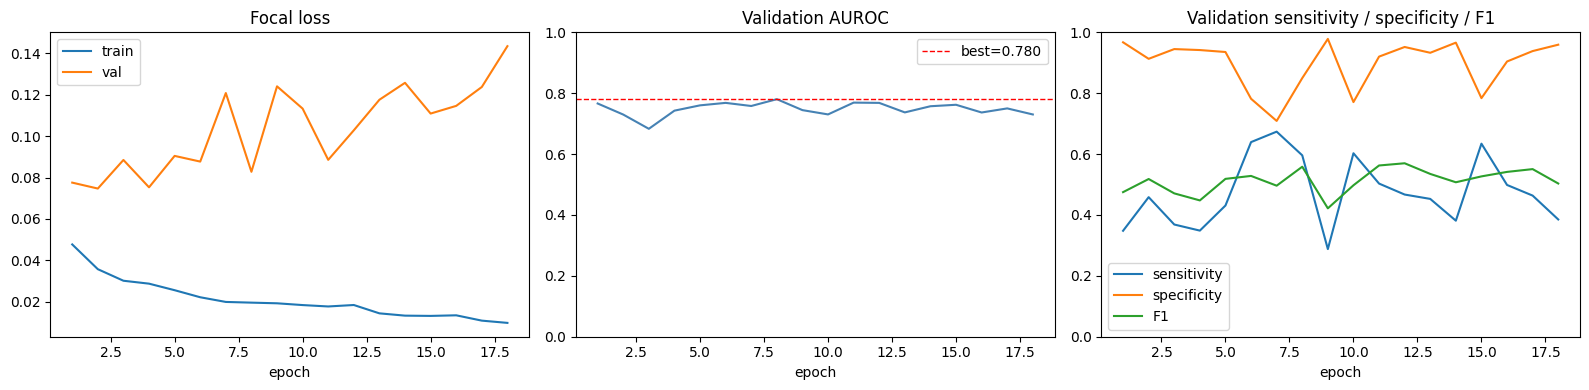

In [9]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_ran, history["train_loss"], label="train")
axes[0].plot(epochs_ran, history["val_loss"], label="val")
axes[0].set_title("Focal loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(epochs_ran, history["val_auc"], color="steelblue")
axes[1].axhline(best_val_auc, ls="--", c="red", lw=1, label=f"best={best_val_auc:.3f}")
axes[1].set_title("Validation AUROC"); axes[1].set_xlabel("epoch"); axes[1].set_ylim(0, 1); axes[1].legend()

axes[2].plot(epochs_ran, history["val_sensitivity"], label="sensitivity")
axes[2].plot(epochs_ran, history["val_specificity"], label="specificity")
axes[2].plot(epochs_ran, history["val_f1"], label="F1")
axes[2].set_title("Validation sensitivity / specificity / F1"); axes[2].set_xlabel("epoch")
axes[2].set_ylim(0, 1); axes[2].legend()

plt.tight_layout()
plt.savefig(CKPT_DIR / "training_curves.png", dpi=130, bbox_inches="tight")
plt.show()


## Test

Reloads the best checkpoint and evaluates once on a held-out-subject test set the model has
never seen a window from -- not the fixed val subsample used for per-epoch tracking above.
`TEST_EVAL_MAX_SAMPLES` in the config bounds how much of the test set this pass reads (a
class-stratified subsample); set it to `None` for the complete test set.

In [10]:
ckpt = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"loaded checkpoint from epoch {ckpt['epoch']} (val AUROC={ckpt['val_auc']:.4f})")

eval_df = test_df if TEST_EVAL_MAX_SAMPLES is None else stratified_sample(
    test_df, min(TEST_EVAL_MAX_SAMPLES, len(test_df)), SEED)
test_loader = DataLoader(WindowDataset(eval_df), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"evaluating on {len(eval_df):,} / {len(test_df):,} test windows "
      f"({int((eval_df.label == 1).sum())} seizure)")

_, test_probs, test_labels = run_epoch(model, test_loader, criterion)
test_preds = (test_probs >= 0.5).astype(int)

print("\n" + "=" * 55)
print("TEST SET RESULTS (threshold=0.5)")
print("=" * 55)
print(classification_report(test_labels, test_preds, target_names=["non-seizure", "seizure"], digits=4))

m = binary_metrics(test_probs, test_labels)
tn, fp, fn, tp = confusion_matrix(test_labels, test_preds, labels=[0, 1]).ravel()
far = fp / (fp + tn + 1e-8)
print(f"ROC-AUC              : {m['auc']:.4f}")
print(f"Sensitivity (recall)  : {m['sensitivity']:.4f}  <- most clinically critical")
print(f"Specificity           : {m['specificity']:.4f}")
print(f"False alarm rate      : {far:.4f}")
print(f"Confusion matrix: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")


loaded checkpoint from epoch 8 (val AUROC=0.7804)
evaluating on 15,000 / 73,170 test windows (2170 seizure)



TEST SET RESULTS (threshold=0.5)
              precision    recall  f1-score   support

 non-seizure     0.9566    0.7200    0.8216     12830
     seizure     0.3277    0.8069    0.4661      2170

    accuracy                         0.7326     15000
   macro avg     0.6422    0.7635    0.6439     15000
weighted avg     0.8656    0.7326    0.7702     15000

ROC-AUC              : 0.8509
Sensitivity (recall)  : 0.8069  <- most clinically critical
Specificity           : 0.7200
False alarm rate      : 0.2800
Confusion matrix: TN=9,238 FP=3,592 FN=419 TP=1,751


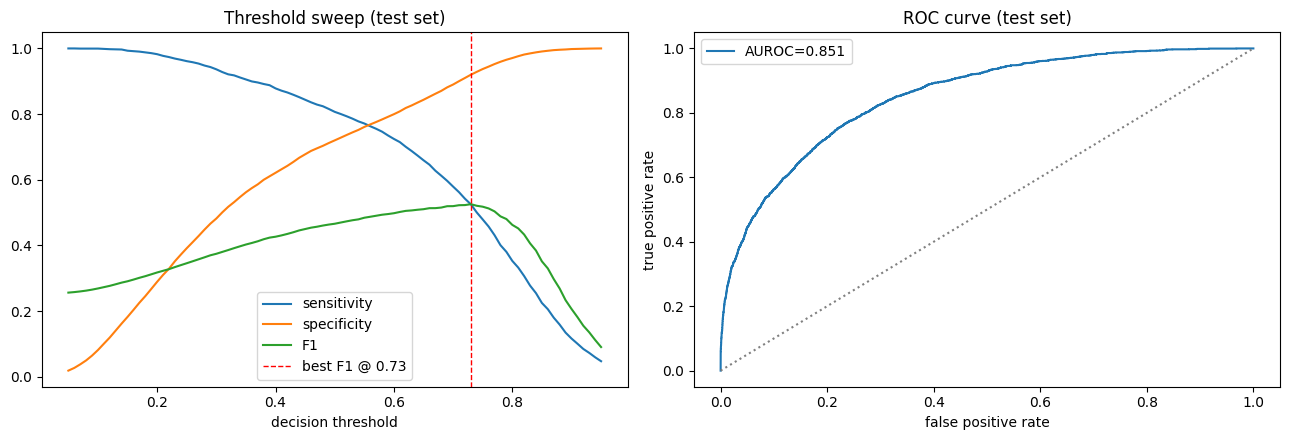

best-F1 threshold: 0.73  (sensitivity=0.525, specificity=0.920, F1=0.526)


In [11]:
# Threshold sweep -- 0.5 is rarely optimal under this much class imbalance.
thresholds = np.linspace(0.05, 0.95, 91)
sens, spec, f1s = [], [], []
for t in thresholds:
    preds = (test_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_labels, preds, labels=[0, 1]).ravel()
    sens.append(tp / (tp + fn + 1e-8))
    spec.append(tn / (tn + fp + 1e-8))
    f1s.append(f1_score(test_labels, preds, zero_division=0))
best_t = thresholds[int(np.argmax(f1s))]

fpr, tpr, _ = roc_curve(test_labels, test_probs)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(thresholds, sens, label="sensitivity")
axes[0].plot(thresholds, spec, label="specificity")
axes[0].plot(thresholds, f1s, label="F1")
axes[0].axvline(best_t, ls="--", c="red", lw=1, label=f"best F1 @ {best_t:.2f}")
axes[0].set_xlabel("decision threshold"); axes[0].set_title("Threshold sweep (test set)"); axes[0].legend()

axes[1].plot(fpr, tpr, label=f"AUROC={m['auc']:.3f}")
axes[1].plot([0, 1], [0, 1], ls=":", c="grey")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve (test set)"); axes[1].legend()

plt.tight_layout()
plt.savefig(CKPT_DIR / "test_threshold_roc.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"best-F1 threshold: {best_t:.2f}  (sensitivity={sens[np.argmax(f1s)]:.3f}, "
      f"specificity={spec[np.argmax(f1s)]:.3f}, F1={max(f1s):.3f})")


## Notes

- This is a **window-level** detector. A deployed system would smooth predictions over
  consecutive windows per recording before alarming -- not implemented here, out of scope for
  a per-model train/test notebook.
- The test set above is held out at the **subject** level; no window from a test-set subject
  was seen during training or model selection.
- Stage 2 (`src/model_stage2_cnn1d_subtype.ipynb`) picks up only where this model would say
  "seizure" -- it classifies *which* seizure subtype, Siena-only, and needs leave-one-subject-out
  evaluation rather than this train/val/test split (see that notebook for why).